# Fitting procedures and heavy computations notebook

## imports and setup

In [1]:
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import pickle
from scipy import stats

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *
from initialize_notebook import initialize_notebook

plt.style.use('./Figures/paper.mplstyle')

In [2]:
root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS = initialize_notebook()
intact_rats, DSlesioned_rats, VSlesioned_rats, sham_rats, all_rats = rat_lists
alpha, alpha_t, alpha_U, gamma, gamma_t, gamma_U, mu, mu_t, mu_U, sigma, sigma_t, sigma_U = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))


Found 84 rats in the DATA folder
Listed 57 rats in total, of which 19 are intact (8♀, 11♂), 19 DS lesions, 15 VS lesions and 4 shams.
Example rat is RatM00, example session: RatM00_2021_07_22_16_13_03


## rat colors and reload pickled data

In [3]:
params = {}
sequence = {}
XtrackRunToLeftBin = {}
XtrackRunToRightBin = {}

for index, animal in enumerate(all_rats):
    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal, session, name="sequence.p")
        params[animal, session]   = get_from_pickle(root, animal, session, name="params.p")
        XtrackRunToLeftBin[animal, session], XtrackRunToRightBin[animal, session] = get_from_pickle(root, animal, session, name="trackPos.p")

## bin the data (10min time bins and with reward history)

In [4]:
# # separate the data into time and reward bins for each experimental condition
# # distances 
# data60IDLE = prepare_data_idle_times(sequence, all_rats, dist60)
# data90IDLE = prepare_data_idle_times(sequence, all_rats, dist90)
# data120IDLE = prepare_data_idle_times(sequence, all_rats, dist120)

# data60RUN = prepare_data_running_times(sequence, all_rats, dist60)
# data90RUN = prepare_data_running_times(sequence, all_rats, dist90)
# data120RUN = prepare_data_running_times(sequence, all_rats, dist120)

# # treadmill speeds
# data20IDLE = prepare_data_idle_times(sequence, all_rats, TM20)
# data10IDLE = prepare_data_idle_times(sequence, all_rats, TM10)
# data2IDLE = prepare_data_idle_times(sequence, all_rats, TM2+TMrev2)
# datarev10IDLE = prepare_data_idle_times(sequence, all_rats, TMrev10)
# datarev20IDLE = prepare_data_idle_times(sequence, all_rats, TMrev20)

# data20RUN = prepare_data_running_times(sequence, all_rats, TM20)
# data10RUN = prepare_data_running_times(sequence, all_rats, TM10)
# data2RUN = prepare_data_running_times(sequence, all_rats, TM2+TMrev2)
# datarev10RUN = prepare_data_running_times(sequence, all_rats, TMrev10)
# datarev20RUN = prepare_data_running_times(sequence, all_rats, TMrev20)

# # all conditions pooled
# dataAllIDLE = prepare_data_idle_times(sequence, all_rats, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)
# dataAllRUN = prepare_data_running_times(sequence, all_rats, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)


# Effort sensitivity ς0, ςt, ςu

## compute running distance

In [5]:
realdist60 = {}
realdist90 = {}
realdist120= {}

# compute the running distance for each run (pos start - pos end) for each distance configuration
for animal in all_rats:
    realdist60[animal], realdist90[animal], realdist120[animal] = ([] for _ in range(3))
    for session in sorted(matchsession(animal, dist60)):
        for i in range(0, 12):
            realdist60[animal] = np.append(realdist60[animal], [abs(r[0] - r[-1]) for r in XtrackRunToRightBin[animal, session][i]])
            realdist60[animal] = np.append(realdist60[animal], [abs(l[0] - l[-1]) for l in XtrackRunToLeftBin[animal, session][i]])
    for session in sorted(matchsession(animal, dist90)):   
        for i in range(0, 12):
            realdist90[animal] = np.append(realdist90[animal], [abs(r[0] - r[-1]) for r in XtrackRunToRightBin[animal, session][i]])
            realdist90[animal] = np.append(realdist90[animal], [abs(l[0] - l[-1]) for l in XtrackRunToLeftBin[animal, session][i]])
    for session in sorted(matchsession(animal, dist120)):
        for i in range(0, 12):
            realdist120[animal] = np.append(realdist120[animal], [abs(r[0] - r[-1]) for r in XtrackRunToRightBin[animal, session][i]])
            realdist120[animal] = np.append(realdist120[animal], [abs(l[0] - l[-1]) for l in XtrackRunToLeftBin[animal, session][i]])

# compute the mean running distance for each animal for each distance configuration
medianrealdist60 = {}
medianrealdist90 = {}
medianrealdist120 = {}

for animal in all_rats:
    medianrealdist60[animal] = np.median(realdist60[animal]) / 100
    medianrealdist90[animal] = np.median(realdist90[animal]) / 100
    medianrealdist120[animal] = np.median(realdist120[animal]) / 100



## Define model

In [6]:
def T_opt(D, vbelt, effort_sensitivity, power_effort, power_time=3):
    'dirty find optimal time for a given distance, belt speed, and reward size'
    T = np.linspace(0.0, 2.5, 1000)
    vmax = (D - vbelt * T) / (T)
    cost = effort_sensitivity * T * vmax ** power_effort + T**power_time
    Topt = T[np.nanargmin(cost)]
    return Topt

# function to compute the loss function for the effort model
def effort_loss(params, *args):

    effort_sensitivity_0, effort_sensitivity_t, effort_sensitivity_U, power_0 = params
    fit_params, realdist, N_bins, N_avg, return_residuals = args
    mu_0, mu_t, mu_U = fit_params
    S, M, L = realdist

    conds = ["60", "90", "120", "20", "10", "2", "rev10", "rev20"]
    params_distance = {"60": S, "90": M, "120": L, "20": L, "10": L, "2": L, "rev10": L, "rev20": L}
    params_vbelt = {"60": 0, "90": 0, "120": 0, "20": .2, "10": .1, "2": .02, "rev10": -.1, "rev20": -.2}

    residuals =[]
    loss = 0
    MU = {key: np.zeros((N_bins, N_avg)) for key in conds}
    EFFORT_SENSITIVITY = np.zeros((N_bins, N_avg))
    POWER = np.zeros((N_bins, N_avg))

    for cond in conds:
        for bin in range(N_bins):
            for avg in range(N_avg):
                MU[cond][bin, avg] = mu_0[cond] + bin*mu_t[cond] + avg*mu_U[cond]
                EFFORT_SENSITIVITY[bin, avg] = effort_sensitivity_0 + bin*effort_sensitivity_t + avg*effort_sensitivity_U
                POWER[bin, avg] = power_0

    for bin in range(N_bins):
        for avg in range(N_avg):
            experimental_data = [MU[cond][bin, avg] for cond in conds]
            theoretical_data = [T_opt(params_distance[cond], params_vbelt[cond], effort_sensitivity=EFFORT_SENSITIVITY[bin, avg], power_effort=POWER[bin, avg]) for cond in conds]
            diff = np.array(experimental_data) - np.array(theoretical_data)
            residuals.append(diff)
            loss += np.sum(diff**2)

    residuals = np.array(residuals)
    if return_residuals:
        return loss, residuals
    return loss

def effort_fit(mu_0, mu_t, mu_U, 
                realdist60, realdist90, realdist120, 
                init=[12, 5, 1, 3], 
                f=effort_loss, N_bins=6, N_avg=4,
                effort_sensitivity_t_fixed=False,
                effort_sensitivity_U_fixed=False,
                power_0_fixed=False,
                return_residuals=False):
    
    params_init = np.array(init)
    effort_sensitivity_t_bounds = (None, None) if not effort_sensitivity_t_fixed else (0, 1e-8)
    effort_sensitivity_U_bounds = (None, None) if not effort_sensitivity_U_fixed else (0, 1e-8)
    power_0_bounds = (None, None) if not power_0_fixed else (2, 2+1e-8)

    res = minimize(f, params_init, 
                    args=((mu_0, mu_t, mu_U), (realdist60, realdist90, realdist120, ), N_bins, N_avg, return_residuals),
                    method='nelder-mead', options={'xatol': 1e-9}, 
                    bounds=[(0, None), effort_sensitivity_t_bounds, effort_sensitivity_U_bounds, power_0_bounds]
                    )
    return res.x, res.fun

animal = 'RatF41'
p, l = effort_fit(mu[animal], mu_t[animal], mu_U[animal], medianrealdist60[animal], medianrealdist90[animal], medianrealdist120[animal])
print(p, l)
loss, residuals = effort_loss(p, (mu[animal], mu_t[animal], mu_U[animal]),
               (medianrealdist60[animal], medianrealdist90[animal], medianrealdist120[animal]), 6, 4, True)
print('***', loss, residuals)

/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in true_divide
  after removing the cwd from sys.path.
/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in multiply
  """


[54.01500786 11.27017786  0.79683045  2.67933404] 11.222565802778572
*** 11.222565802778572 [[ 0.09774448 -0.22188743 -0.31238732 -0.04167056 -0.09888306 -0.0265776
  -0.0655722  -0.07244028]
 [ 0.06114565 -0.23775161 -0.32447141  0.05941225  0.00187874  0.1184303
   0.03892252 -0.04110361]
 [ 0.02704932 -0.25361579 -0.33405301  0.16049505  0.10013803  0.2659407
   0.14341723 -0.00976694]
 [-0.00704701 -0.26947997 -0.34613711  0.26157786  0.20089983  0.41094859
   0.24791195  0.02156974]
 [ 0.06834413 -0.24741761 -0.35545731 -0.03156136 -0.09404031 -0.01576932
  -0.05134569 -0.052283  ]
 [ 0.03174529 -0.26328179 -0.36503891  0.07202396  0.00672149  0.13174108
   0.05565153 -0.01844382]
 [-0.00235104 -0.27914597 -0.3746205   0.17310676  0.10748329  0.27925148
   0.16014624  0.01539535]
 [-0.03644736 -0.29250765 -0.3842021   0.27418957  0.20824508  0.42425937
   0.26714346  0.04673203]
 [ 0.04394877 -0.26544028 -0.3860148  -0.00893963 -0.07918754  0.00504897
  -0.02460667 -0.0171107 ]
 [

In [7]:

# all_residuals = []
avgresiduals = {animal: [] for animal in all_rats}
effort_sensitivity_0, effort_sensitivity_t, effort_sensitivity_U, power_0 = pickle.load(open("picklejar/effort_sensitivity_fit.p", "rb"))
for animal in all_rats:
    loss, residuals = effort_loss((effort_sensitivity_0[animal], effort_sensitivity_t[animal], effort_sensitivity_U[animal], power_0[animal]),
                                  (mu[animal], mu_t[animal], mu_U[animal]),
                                  (medianrealdist60[animal], medianrealdist90[animal], medianrealdist120[animal]),
                                  6, 4, True)
    # if animal in intact_rats:
    #     all_residuals.append(residuals)
    avgresiduals[animal] = np.mean(residuals, axis=0)  # average across time bins and reward averages
    print(animal, loss)

RatF00 0.7265494567446581
RatF01 1.3468832554251158
RatF02 2.250294441604214
RatM00 2.6239820383331245
RatM01 1.8796749930684304
RatM02 3.059440305620921
RatF32 2.0700438635739147
RatF33 2.015222917034247
RatM31 0.6429648952712939
RatM32 1.7105446972512006


/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in true_divide
  after removing the cwd from sys.path.
/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in multiply
  """


RatF42 1.5388531546376236
RatM40 1.6281313446320933
RatM43 0.41626516210499825
RatM53 2.1001768289005494
RatM54 1.741193485443612
Raz41F 1.9471606110939965
Raz42F 1.4279327201500978
Raz46M 0.5034115823469725
Raz47M 0.4428715116773818
RatF30 5.643382644751569
RatF31 5.664907819024593
RatM30 3.042047918126019
RatF40 0.9785981651113934
RatF41 11.222565802778572
RatM41 1.7964679211216876
RatM42 0.7450836358819691
RatF50 2.0390481911652447
RatF51 1.2980879689223654
RatF52 2.03684447033139
RatM50 1.437527201059014
RatM51 4.050546676397368
RatM52 2.0342487242703466
Raz55M 8.726711110214811
Raz63F 1.6399201086028805
Raz64F 2.137351313408066
Raz65M 4.057188190401899
Raz66M 2.343632116962481
Raz67M 16.179781014323318
Raz10F 2.3454715259008916
Raz11F 1.4588293740980194
Raz13F 6.393590283919502
Raz16M 1.1340367414952246
Raz30F 2.1228742644243086
Raz31F 1.5479646871730492
Raz33M 1.750183884087191
Raz34M 3.551898074971808
Raz35M 2.0500560579199845
Raz40F 1.7447839327137495
Raz44M 0.6872908674931799


In [ ]:
# all_residuals = np.array(all_residuals)
# print(all_residuals.shape)
# flat = all_residuals.reshape(-1, all_residuals.shape[-1])
# print(flat.shape)
# flatflat = flat.reshape(-1)
# print(flatflat.shape)


# import matplotlib.pyplot as plt
# import scipy.stats as stats

def check_gaussian_residuals(residuals):
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))

    ax[0].hist(residuals, bins=30, density=True, alpha=0.6)
    x = np.linspace(residuals.min(), residuals.max(), 200)
    ax[0].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()))
    ax[0].set_title("Residuals histogram")

    stats.probplot(residuals, dist="norm", plot=ax[1])
    ax[1].set_title("QQ plot")

    plt.tight_layout()
    plt.show()

# check_gaussian_residuals(flatflat, title="Effort model residuals across all rats and conditions")





In [12]:
# x = np.arange(8)
# for sublist in flat:
#     plt.plot(x, sublist, color='gray', alpha=0.3)
# plt.plot(x, np.mean(flat, axis=0), color='k', linewidth=2)
# plt.xticks(x, ['60', '90', '120', '20', '10', '2', 'rev10', 'rev20'])
# plt.xlabel('Experimental condition')
# plt.ylabel('Residual (s)')

/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:24: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 


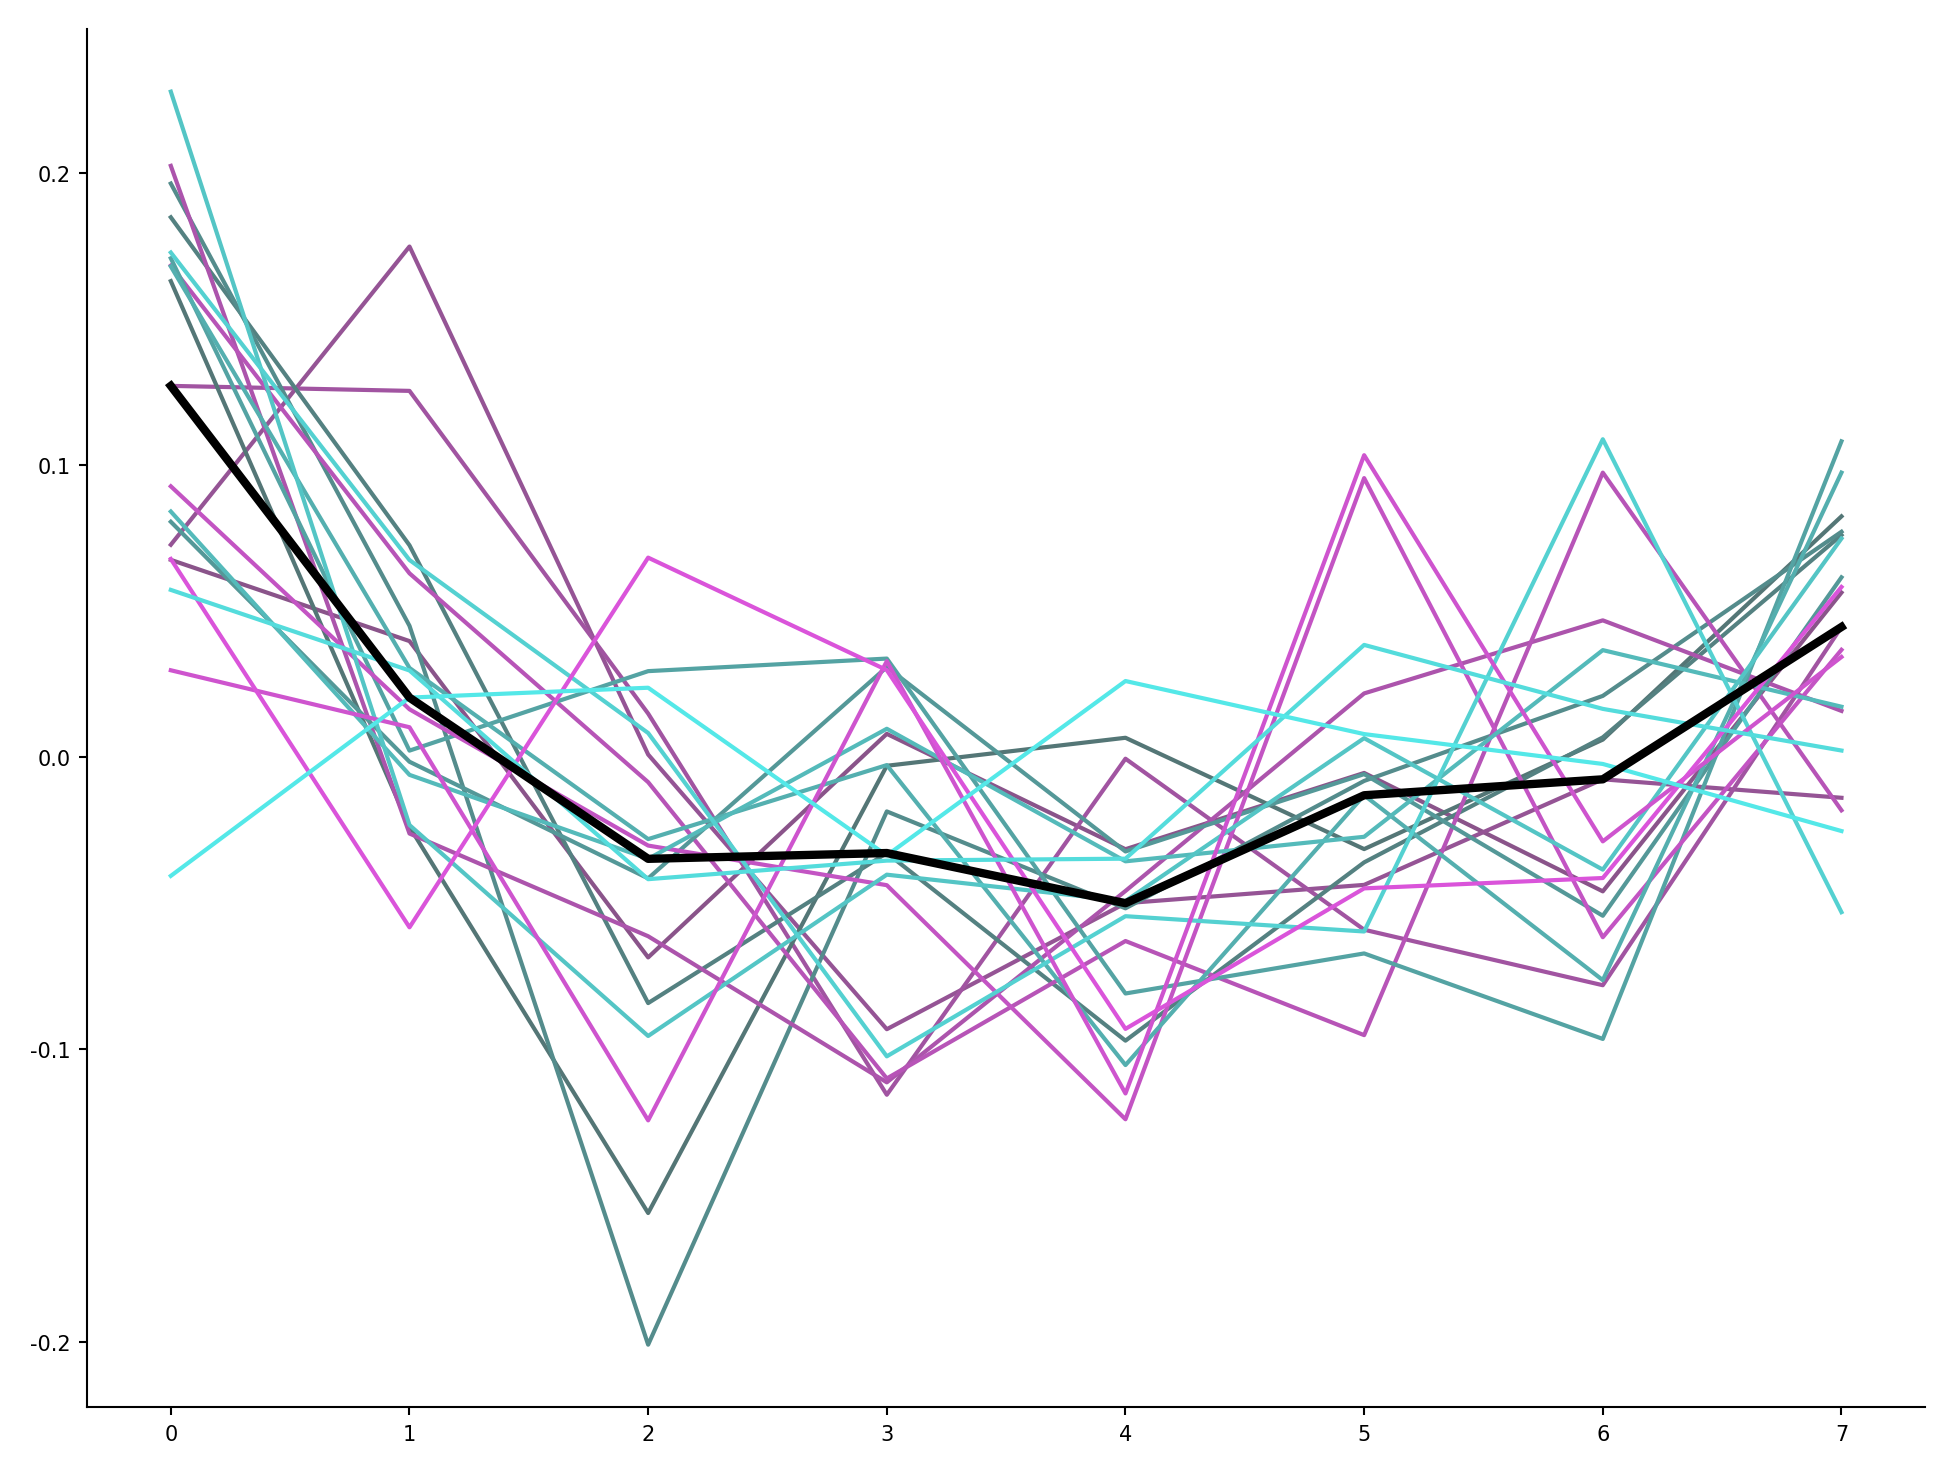

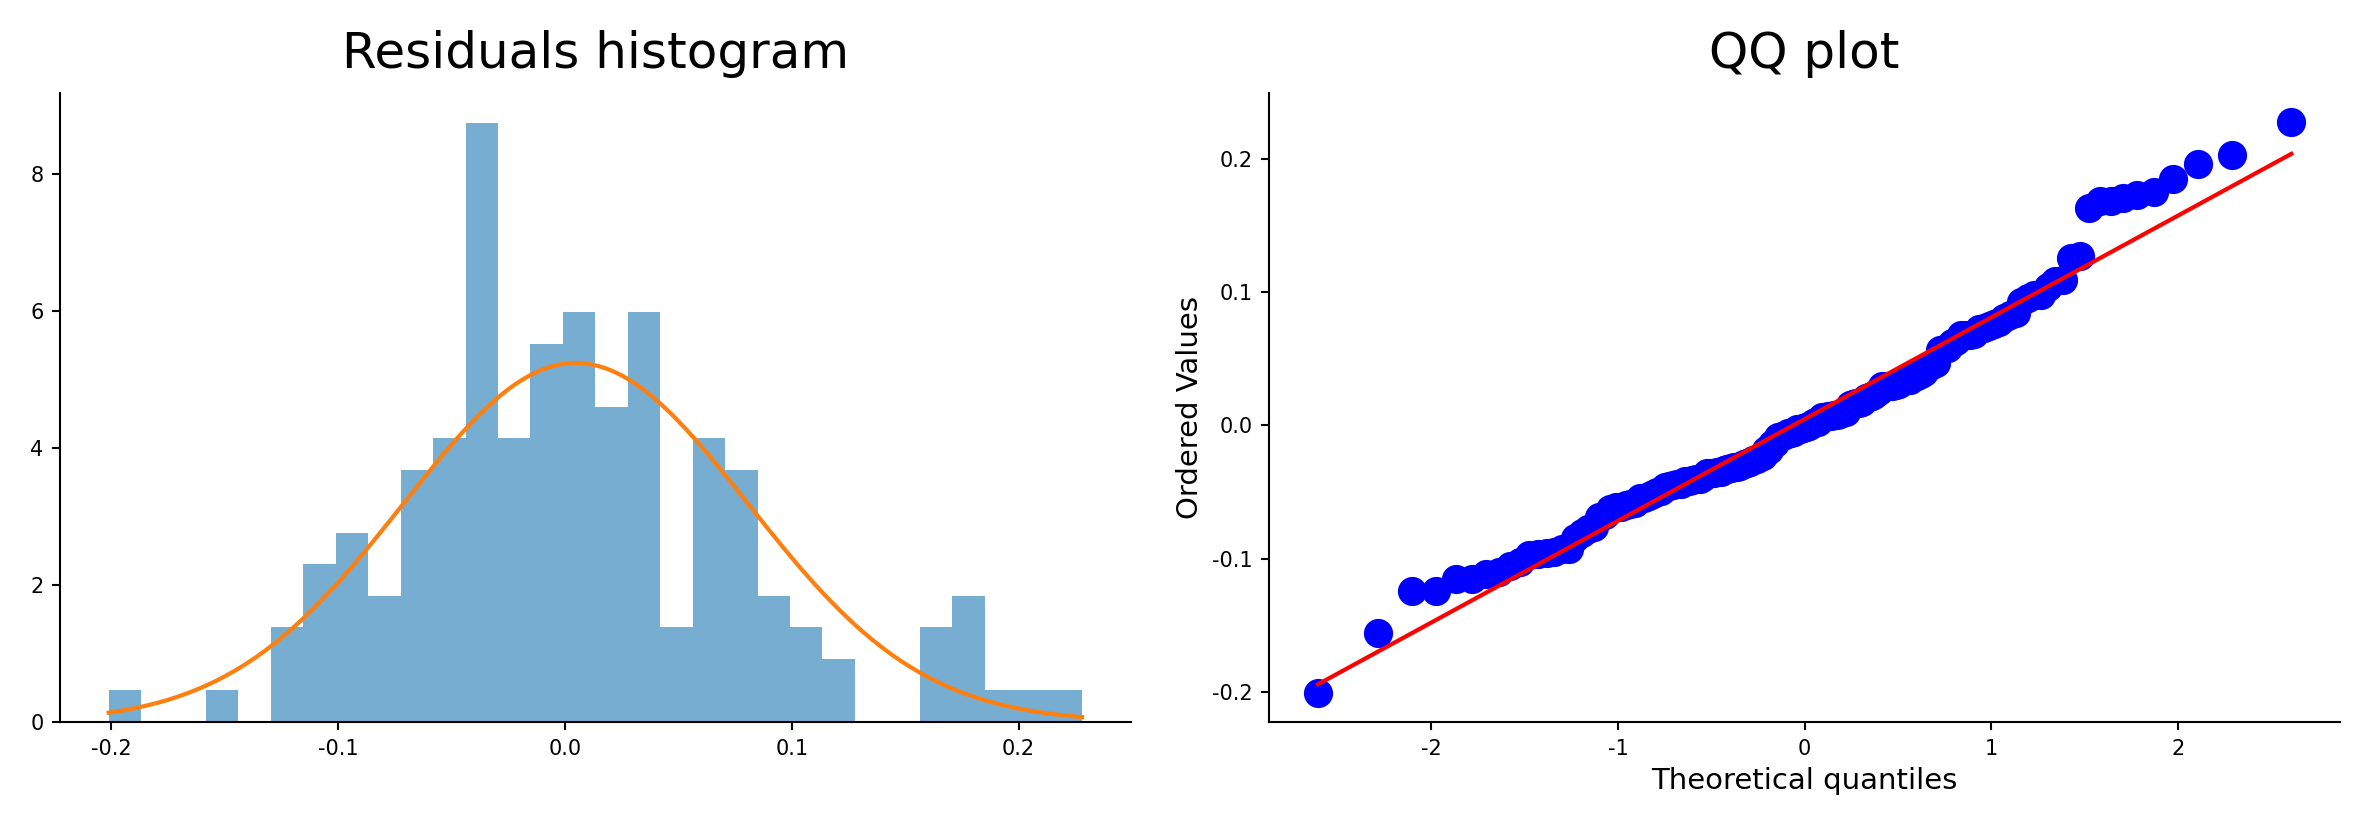

In [13]:

x = np.arange(8)
for animal in intact_rats:
    plt.plot(x, avgresiduals[animal], color=rat_markers[animal][0])


only_intact = {k: v for k, v in avgresiduals.items() if k in intact_rats}
values = np.array(list(only_intact.values()))

median_values = np.median(values, axis=0)
plt.plot(x, median_values, color='black', linewidth=2, label='Median')


check_gaussian_residuals(values.reshape(-1))



/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:41: UserWarning: 

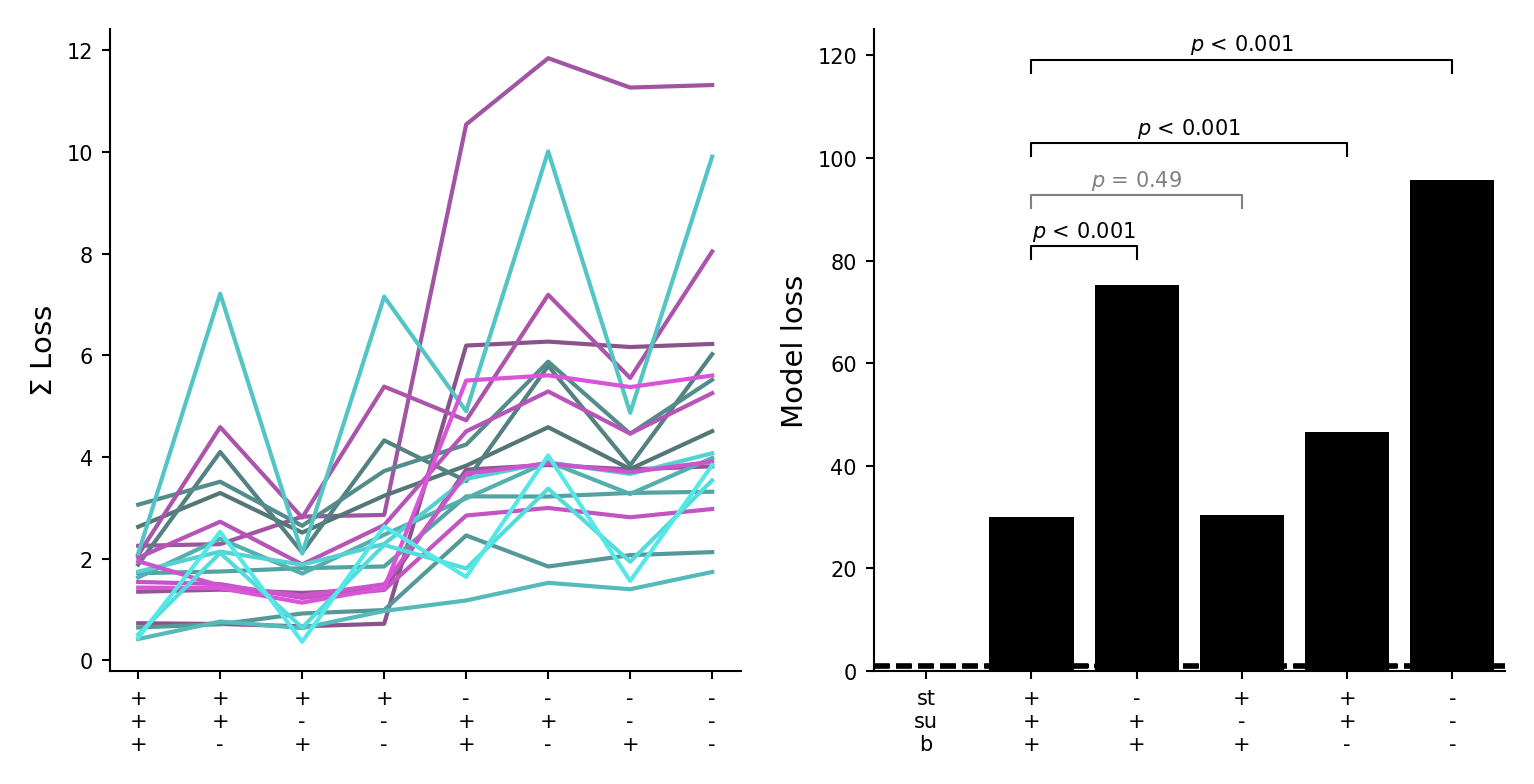

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(5, 2.5))

the_keys_i_want = [(False, False, False), 
                    (True, False, False), 
                    (False, True, False), 
                    (False, False, True), 
                    (True, True, True)]


if os.path.exists("picklejar/ablationLossesEffort.p"):
    ablation_losses = pickle.load(open("picklejar/ablationLossesEffort.p", "rb"))
else:
    ablation_losses = {}
    for animal in intact_rats:
        ablation_losses[animal] = {}
        for effort_sensitivity_t_fixed in [False, True]:
            for effort_sensitivity_U_fixed in [False, True]:
                for power_0_fixed in [False, True]:
                    number_of_params = 1  # effort_sensitivity_0
                    number_of_extra_params = effort_sensitivity_t_fixed + effort_sensitivity_U_fixed + power_0_fixed
                    _, loss = effort_fit(mu[animal], mu_t[animal], mu_U[animal],
                                         medianrealdist60[animal], medianrealdist90[animal], medianrealdist120[animal],
                                         effort_sensitivity_t_fixed=effort_sensitivity_t_fixed,
                                         effort_sensitivity_U_fixed=effort_sensitivity_U_fixed,
                                         power_0_fixed=power_0_fixed)
                    k = number_of_params + (3 - number_of_extra_params)
                    N = 8 * 6 * 4  # conditions * bins * rwd
                    sse = loss
                    BIC = k * np.log(N) + N * np.log(sse / N)
                    print(f'{animal} | params fixed: {effort_sensitivity_t_fixed}, {effort_sensitivity_U_fixed}, {power_0_fixed} | N_params: {k} | Loss: {loss} | BIC: {BIC}')
                                         

                    ablation_losses[animal][(effort_sensitivity_t_fixed, effort_sensitivity_U_fixed, power_0_fixed)] = loss#BIC
    pickle.dump(ablation_losses, open("picklejar/ablationLossesEffort.p", "wb"))


for animal in intact_rats:
    axs[0].plot(np.arange(8), [l for l in ablation_losses[animal].values()], color=rat_markers[animal][0], label=animal)
    axs[0].set_ylabel(r'$\Sigma$ Loss')
    # axs[0].set_xticks(np.arange(-1, 16))
    axs[0].set_xticklabels(dict_to_xticklabels(ablation_losses[animal], labels=['st', 'su', 'b']))
    # axs[0].set_xlim([-1.5, 16.5])

    for i, key in enumerate(the_keys_i_want):
        axs[1].bar(i+1, np.sum([ablation_losses[animal][key] for animal in intact_rats]), color='k', label='sum', )
    axs[1].set_ylabel('Model loss')
    axs[1].set_xticks(np.arange(6))
    axs[1].set_xticklabels(dict_to_xticklabels({k:ablation_losses[animal][k] for k in the_keys_i_want}, labels=['st', 'su', 'b']))
    # axs[1].set_ylim([900, 1250])
    axs[1].set_xlim([-.5, 5.5])
    axs[1].axhline(1, color='k', linestyle='--')

def LLratio_vs_complete_sse(ablation_losses, keys, animal_list, ax=None):
    if ax is None: fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    LL_sums = [np.sum([ablation_losses[animal][key] for animal in animal_list]) for key in keys]
    LL_complete = LL_sums[0]
    LL_reduced = LL_sums[1:]
    dParams = [np.sum(key) for key in keys][1:]

    N = 8 * 6 * 4  # conditions * bins * rwd
    p_vals = np.zeros(len(dParams))
    for i, (reducted_model_loss, df) in enumerate(zip(LL_reduced, dParams)):
        LR = N * np.log(reducted_model_loss / LL_complete)
        p_vals[i] = stats.chi2.sf(LR, df)

    sig, corrected_pvals, alphabonf = multipletests_bonferroni(p_vals)
    for i, p_val in enumerate(corrected_pvals):
        barplot_annotate_brackets(ax, 0, i+1, p_val, np.arange(1, 7), 
                                  [LL_complete]*6, 
                                  dh=0.5+i*.1, barh=.025, maxasterix=None)

LLratio_vs_complete_sse(ablation_losses, the_keys_i_want, intact_rats, axs[1])

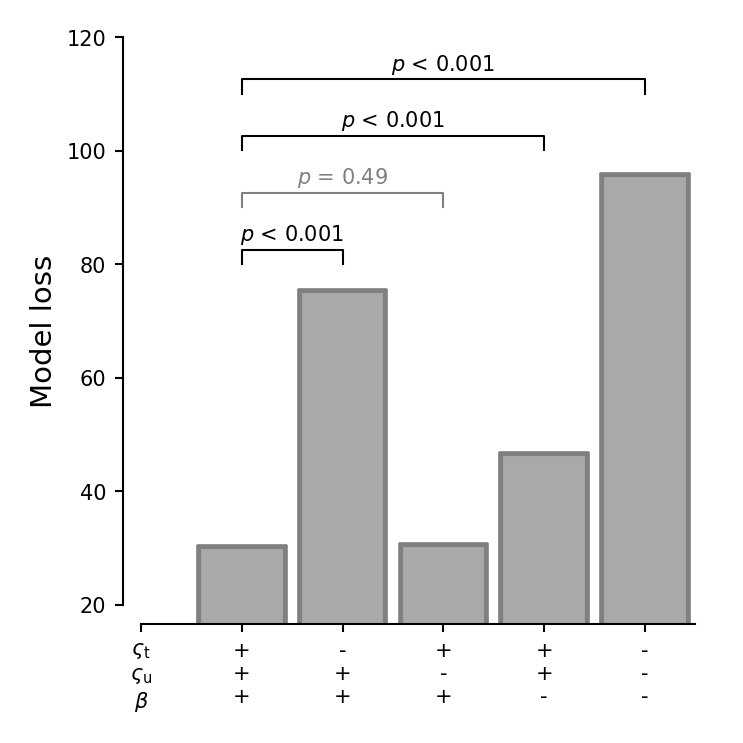

In [15]:

def FigureSXX(animal_list=intact_rats, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(cm2inch(6), cm2inch(6)))

    the_keys_i_want = [(False, False, False), 
                    (True, False, False), 
                    (False, True, False), 
                    (False, False, True), 
                    (True, True, True)]

    ablation_losses = pickle.load(open("picklejar/ablationLossesEffort.p", "rb"))
    for animal in animal_list:
        for i, key in enumerate(the_keys_i_want):
            ax.bar(i+1, np.sum([ablation_losses[animal][key] for animal in animal_list]), 
                   color='gray', width=.85, facecolor='darkgray', edgecolor='gray', lw=1, zorder=1)

        ax.set_ylabel('Model loss')
        ax.set_xticks(np.arange(6))
        ax.set_xticklabels(dict_to_xticklabels({k:ablation_losses[animal][k] for k in the_keys_i_want}, 
                                               labels=['$\\varsigma_{\mathrm{t}}$', '$\\varsigma_{\mathrm{u}}$', '$\\beta$']))
        ax.set_ylim(20, 120)
        ax.set_yticks([20, 40, 60, 80, 100, 120])
        ax.set_xlim(0, 5.5)
        ax.axhline(1, color='k', linestyle='--')

    LLratio_vs_complete_sse(ablation_losses, the_keys_i_want, animal_list, ax)
    space_axes(ax)

FigureSXX(ax=None)

Total median error: 0.044s


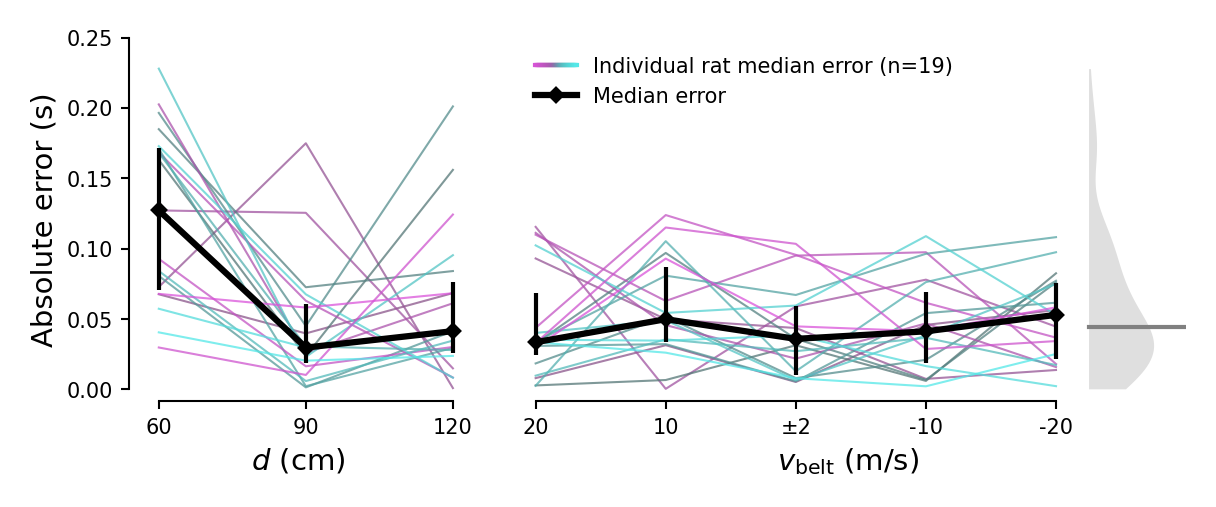

In [16]:
def FigureS7B(error, animal_list=intact_rats, ax_dist=None, ax_vbelt=None):
    if ax_dist is None or ax_vbelt is None:
        fig, (ax_dist, ax_vbelt) = plt.subplots(1, 2, figsize=(cm2inch(12), cm2inch(4)))
    xdist = np.arange(3)
    xvbelt = np.arange(5)

    error = {k: np.abs(v) for k, v in error.items() if k in animal_list}  # filter
    for animal in animal_list:
        ax_dist.plot(xdist, error[animal][:3],
                color=rat_markers[animal][0], ls='-', zorder=5, lw=0.5, alpha=.75)
        ax_vbelt.plot(xvbelt, error[animal][3:],
                color=rat_markers[animal][0], ls='-', zorder=5, lw=0.5, alpha=.75)

    # group median and 25/75 percentiles
    values = np.array(list(error.values()))
    median = np.median(values, axis=0)
    # print(median)
    # print(f'Median of median error: {np.median(median):.4f}s')

    bot, top = 25, 75
    err = []
    for i in range(8):
        percentile_bot = np.percentile([error[animal][i] for animal in animal_list], bot)
        percentile_top = np.percentile([error[animal][i] for animal in animal_list], top)
        err.append([median[i] - percentile_bot, percentile_top - median[i]])
    err = np.array(err).T

    ax_dist.errorbar(xdist, median[:3], yerr=err[:, :3], 
                    capsize=0, color='k', marker='D', markersize=2, linestyle='-', lw=1.5, elinewidth=1, zorder=100)
    ax_vbelt.errorbar(xvbelt, median[3:], yerr=err[:, 3:], 
                    capsize=0, color='k', marker='D', markersize=2, linestyle='-', lw=1.5, elinewidth=1, zorder=100)
    

    yticks = [0, 0.05, 0.1, 0.15, 0.2, 0.25]
    ylim = (0, 0.25)

    ax_dist.set_xlim(xdist[0], xdist[-1])
    ax_dist.set_xticks(xdist)
    ax_dist.set_xticklabels(['60', '90', '120'])
    ax_dist.set_xlabel(f"{r'$d$'} (cm)")
    ax_dist.set_ylabel("Absolute error (s)")
    ax_dist.set_yticks(yticks)
    ax_dist.set_ylim(ylim)
    ax_vbelt.set_xlim(xvbelt[0], xvbelt[-1])
    ax_vbelt.set_xticks(xvbelt)
    ax_vbelt.set_xticklabels(["20", "10", "±2", "-10", "-20"])
    _ = r'$v_{\mathrm{belt}}$'
    ax_vbelt.set_xlabel(f"{_} (m/s)")
    ax_vbelt.set_yticks(yticks)
    ax_vbelt.set_ylim(ylim)
    ax_vbelt.spines['left'].set_visible(False)
    ax_vbelt.tick_params(left=False, labelleft=False)


    space_axes(ax_dist, x_ratio_left=.1, x_ratio_right=0.05)
    space_axes(ax_vbelt, x_ratio_left=0.05,x_ratio_right=.25)

    all_pooled = values.flatten()

    pos = 4.25
    ax_vbelt.plot([pos, pos+1], [np.median(all_pooled)]*2, color='gray')
    print(f'Total median error: {np.median(all_pooled):.3f}s')


    violin_parts = ax_vbelt.violinplot(all_pooled, positions=[pos], showextrema=False, widths=1)
    for pc in violin_parts['bodies']:
        verts = pc.get_paths()[0].vertices
        verts[:, 0] = np.where(verts[:, 0] < pos, pos, verts[:, 0])  
        pc.set_facecolor('gray')
        pc.set_edgecolor('gray')
        pc.set_alpha(0.25)
        pc.set_linewidth(0)

    median_hdl = ax_vbelt.plot([-100, -101], [-100, -101], color='k', marker='D', markersize=2, linestyle='-', lw=1.5,
                    label=f'Median error', zorder=2)
    add_colored_intact(ax_vbelt, handles=[median_hdl],
                    labels=['Median error'], text=f'Individual rat median error (n={len(intact_rats)})', 
                    loc='upper left', bbox=(.01, 1))

fig, axs = plt.subplots(1, 2, figsize=(cm2inch(10), cm2inch(4)), gridspec_kw={'width_ratios': [3, 6]})

only_intact = {k: v for k, v in avgresiduals.items() if k in intact_rats}
FigureS7B(only_intact, ax_dist=axs[0], ax_vbelt=axs[1])

Total median error: 0.044s


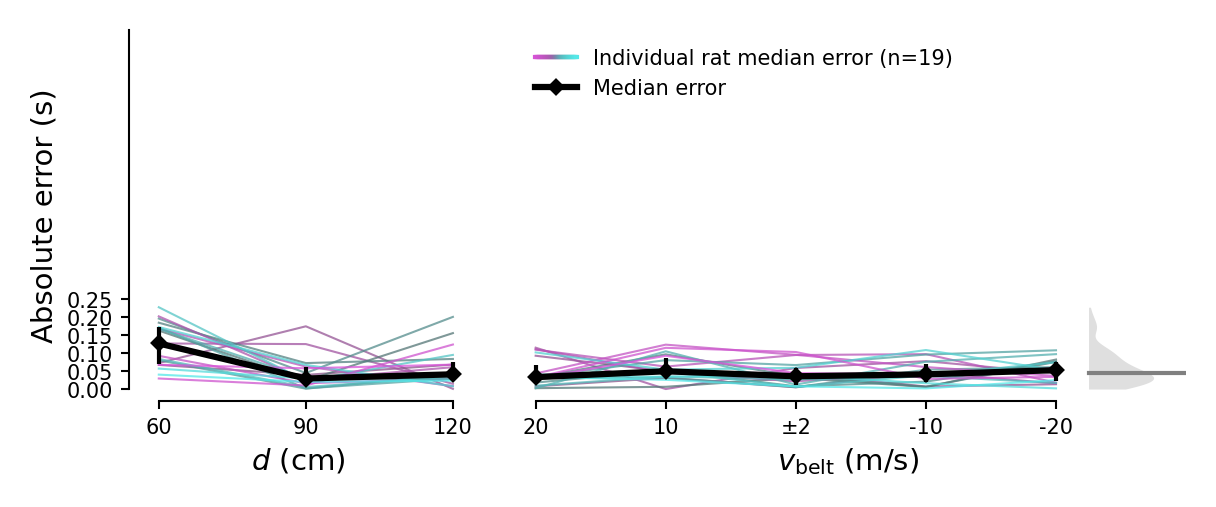

In [17]:
def FigureS7B_(error, animal_list=intact_rats, ax_dist=None, ax_vbelt=None):
    if ax_dist is None or ax_vbelt is None:
        fig, (ax_dist, ax_vbelt) = plt.subplots(1, 2, figsize=(cm2inch(12), cm2inch(4)))
    xdist = np.arange(3)
    xvbelt = np.arange(5)

    error = {k: np.abs(v) for k, v in error.items() if k in animal_list}  # filter
    for animal in animal_list:
        ax_dist.plot(xdist, error[animal][:3],
                color=rat_markers[animal][0], ls='-', zorder=5, lw=0.5, alpha=.75)
        ax_vbelt.plot(xvbelt, error[animal][3:],
                color=rat_markers[animal][0], ls='-', zorder=5, lw=0.5, alpha=.75)

    # group median and 25/75 percentiles
    values = np.array(list(error.values()))
    median = np.median(values, axis=0)
    # print(median)
    # print(f'Median of median error: {np.median(median):.4f}s')

    bot, top = 25, 75
    err = []
    for i in range(8):
        percentile_bot = np.percentile([error[animal][i] for animal in animal_list], bot)
        percentile_top = np.percentile([error[animal][i] for animal in animal_list], top)
        err.append([median[i] - percentile_bot, percentile_top - median[i]])
    err = np.array(err).T

    ax_dist.errorbar(xdist, median[:3], yerr=err[:, :3], 
                    capsize=0, color='k', marker='D', markersize=2, linestyle='-', lw=1.5, elinewidth=1, zorder=100)
    ax_vbelt.errorbar(xvbelt, median[3:], yerr=err[:, 3:], 
                    capsize=0, color='k', marker='D', markersize=2, linestyle='-', lw=1.5, elinewidth=1, zorder=100)
    

    yticks = [0, 0.05, 0.1, 0.15, 0.2, 0.25]
    ylim = (0, 1)

    ax_dist.set_xlim(xdist[0], xdist[-1])
    ax_dist.set_xticks(xdist)
    ax_dist.set_xticklabels(['60', '90', '120'])
    ax_dist.set_xlabel(f"{r'$d$'} (cm)")
    ax_dist.set_ylabel("Absolute error (s)")
    ax_dist.set_yticks(yticks)
    ax_dist.set_ylim(ylim)
    ax_vbelt.set_xlim(xvbelt[0], xvbelt[-1])
    ax_vbelt.set_xticks(xvbelt)
    ax_vbelt.set_xticklabels(["20", "10", "±2", "-10", "-20"])
    _ = r'$v_{\mathrm{belt}}$'
    ax_vbelt.set_xlabel(f"{_} (m/s)")
    ax_vbelt.set_yticks(yticks)
    ax_vbelt.set_ylim(ylim)
    ax_vbelt.spines['left'].set_visible(False)
    ax_vbelt.tick_params(left=False, labelleft=False)


    space_axes(ax_dist, x_ratio_left=.1, x_ratio_right=0.05)
    space_axes(ax_vbelt, x_ratio_left=0.05,x_ratio_right=.25)

    all_pooled = values.flatten()

    pos = 4.25
    ax_vbelt.plot([pos, pos+1], [np.median(all_pooled)]*2, color='gray')
    print(f'Total median error: {np.median(all_pooled):.3f}s')


    violin_parts = ax_vbelt.violinplot(all_pooled, positions=[pos], showextrema=False, widths=1)
    for pc in violin_parts['bodies']:
        verts = pc.get_paths()[0].vertices
        verts[:, 0] = np.where(verts[:, 0] < pos, pos, verts[:, 0])  
        pc.set_facecolor('gray')
        pc.set_edgecolor('gray')
        pc.set_alpha(0.25)
        pc.set_linewidth(0)

    median_hdl = ax_vbelt.plot([-100, -101], [-100, -101], color='k', marker='D', markersize=2, linestyle='-', lw=1.5,
                    label=f'Median error', zorder=2)
    add_colored_intact(ax_vbelt, handles=[median_hdl],
                    labels=['Median error'], text=f'Individual rat median error (n={len(intact_rats)})', 
                    loc='upper left', bbox=(.01, 1))

fig, axs = plt.subplots(1, 2, figsize=(cm2inch(10), cm2inch(4)), gridspec_kw={'width_ratios': [3, 6]})

only_intact = {k: v for k, v in avgresiduals.items() if k in intact_rats}
FigureS7B_(only_intact, ax_dist=axs[0], ax_vbelt=axs[1])

In [18]:
def get_run_speed(example_rat=example_rat, session=example_session, animal_list=[]):

    conds = ["60", "90", "120", "20", "10", "2", "rev10", "rev20"]
    run_speeds = {k: {a: [] for a in conds} for k in animal_list}
    median_run_speeds = {k: {a: [] for a in conds} for k in animal_list}

    for cond, sessionlist in zip(conds, [dist60, dist90, dist120, TM20, TM10, TM2, TMrev10, TMrev20]):
        for animal in animal_list:
            for session in matchsession(animal, sessionlist):
                params = get_from_pickle(root, animal, session, name="params.p")
                for elem in sequence[animal, session]:
                    if get_block(sequence[animal, session][elem][0]) <= 1:
                        if sequence[animal, session][elem][1] == 'run':
                            tm_speed = params['treadmillSpeed'][get_block(sequence[animal, session][elem][0])]
                            run_speeds[animal][cond].append(abs(sequence[animal, session][elem][-1]) - tm_speed)
    for animal in animal_list:
        for cond in conds:
            median_run_speeds[animal][cond] = np.median(run_speeds[animal][cond])

    # for Fig 5
    if example_rat in animal_list:
        pickle.dump([np.median(run_speeds[example_rat][cond]) for cond in conds], open("picklejar/example_rat_run_speeds.p", "wb"))

        # example session
        example_session_run_speeds = []
        params = get_from_pickle(root, example_rat, example_session, name="params.p")
        for elem in sequence[example_rat, example_session]:
            if get_block(sequence[example_rat, example_session][elem][0]) <= 1:
                if sequence[example_rat, example_session][elem][1] == 'run':
                    tm_speed = params['treadmillSpeed'][get_block(sequence[example_rat, example_session][elem][0])]
                    example_session_run_speeds.append(abs(sequence[example_rat, example_session][elem][-1]) - tm_speed)

        return median_run_speeds, np.median(example_session_run_speeds)
    return median_run_speeds, 0

run_speeds, ex_run_speed = get_run_speed(animal_list=intact_rats)
run_speeds_lesion, _ = get_run_speed(animal_list=DSlesioned_rats+VSlesioned_rats)


PLOT_PARAMS = {
    'run_speed': dict(fit=run_speeds, ex_fit=ex_run_speed, yticks=[20, 40, 60, 80, 100, ], ylabel='Run Speed', start='med', end=1),
    'run_speed_lesion': dict(fit=run_speeds_lesion, ex_fit=0, yticks=[20, 40, 60, 80, 100, ], ylabel='Run Speed', start='med', end=1)
}


p_s=0.000, p_i=0.000, obs_slope=15.923, obs_intercept=37.687
p_s=0.000, p_i=0.000, obs_slope=7.547, obs_intercept=54.075


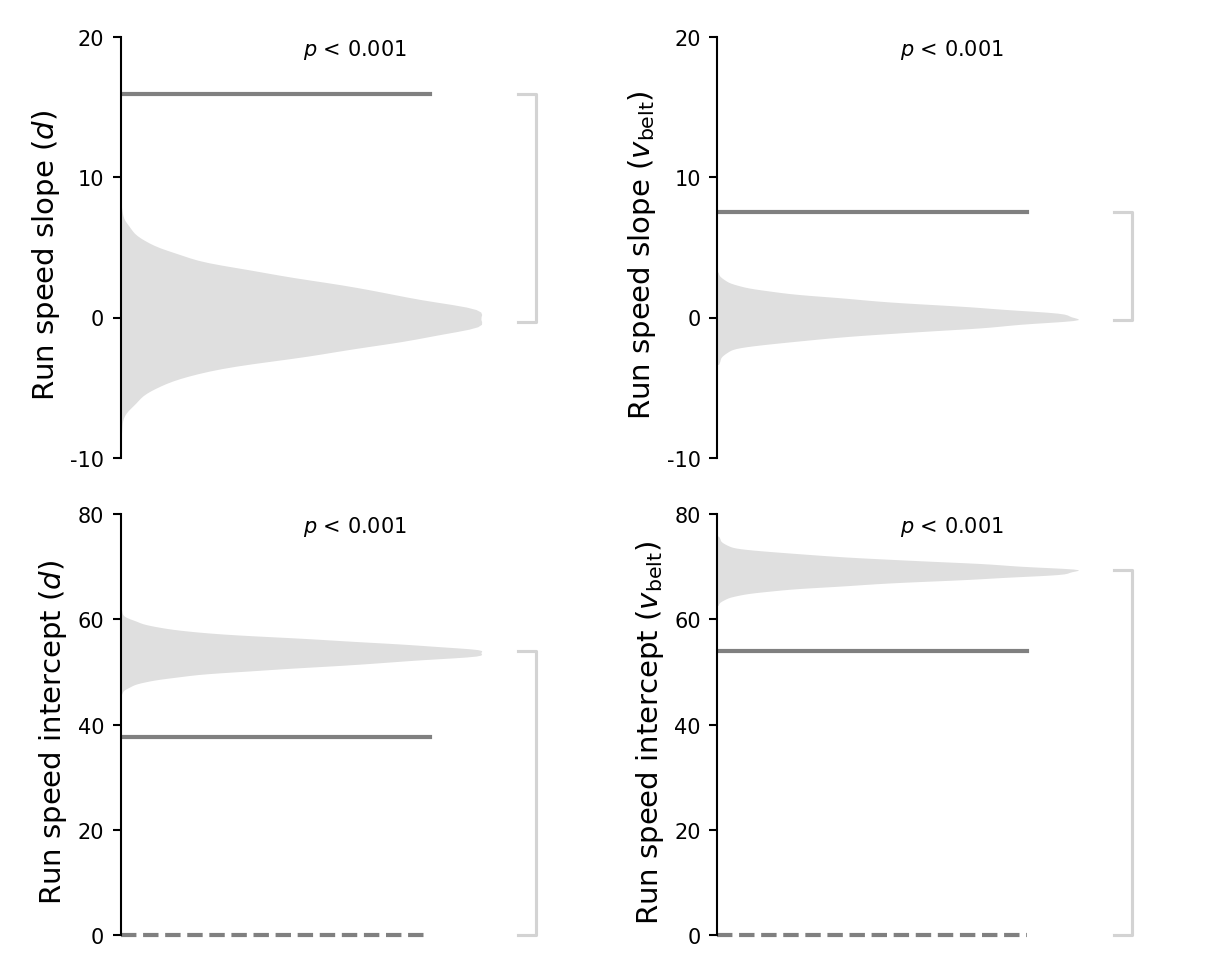

In [19]:
fig, ((ax_slope_dist_intact, ax_slope_tm_intact), (ax_intercept_dist_intact, ax_intercept_tm_intact)) = plt.subplots(2, 2, figsize=(cm2inch(10), cm2inch(8)))
_ = r'$d$'
__ = r'$v_{\mathrm{belt}}$'
regression_permutation(run_speeds, dist_or_tm='dist', animal_list=intact_rats, color='gray',
                       varname_slope=r'Run speed slope ($d$)',
                        varname_intercept=r'Run speed intercept ($d$)',
                        ax_slope=ax_slope_dist_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_intact, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds, dist_or_tm='tm', animal_list=intact_rats, color='gray',
                       varname_slope=r'Run speed slope ($v_{\mathrm{belt}}$)',
                        varname_intercept=r'Run speed intercept ($v_{\mathrm{belt}}$)',
                        ax_slope=ax_slope_tm_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_intact, y_ticks_intercept=[0, 20, 40, 60, 80])



p_s=0.000, p_i=0.000, obs_slope=15.923, obs_intercept=37.687
p_s=0.000, p_i=0.000, obs_slope=7.547, obs_intercept=54.075
Total median error: 0.044s
Panel A: (0.00588009999999996, 0.9867697749999994)
Panel B: (0.005880099999999964, 0.5750050691176467)
Panel C: (0.37022676210448774, 0.5750050691176466)


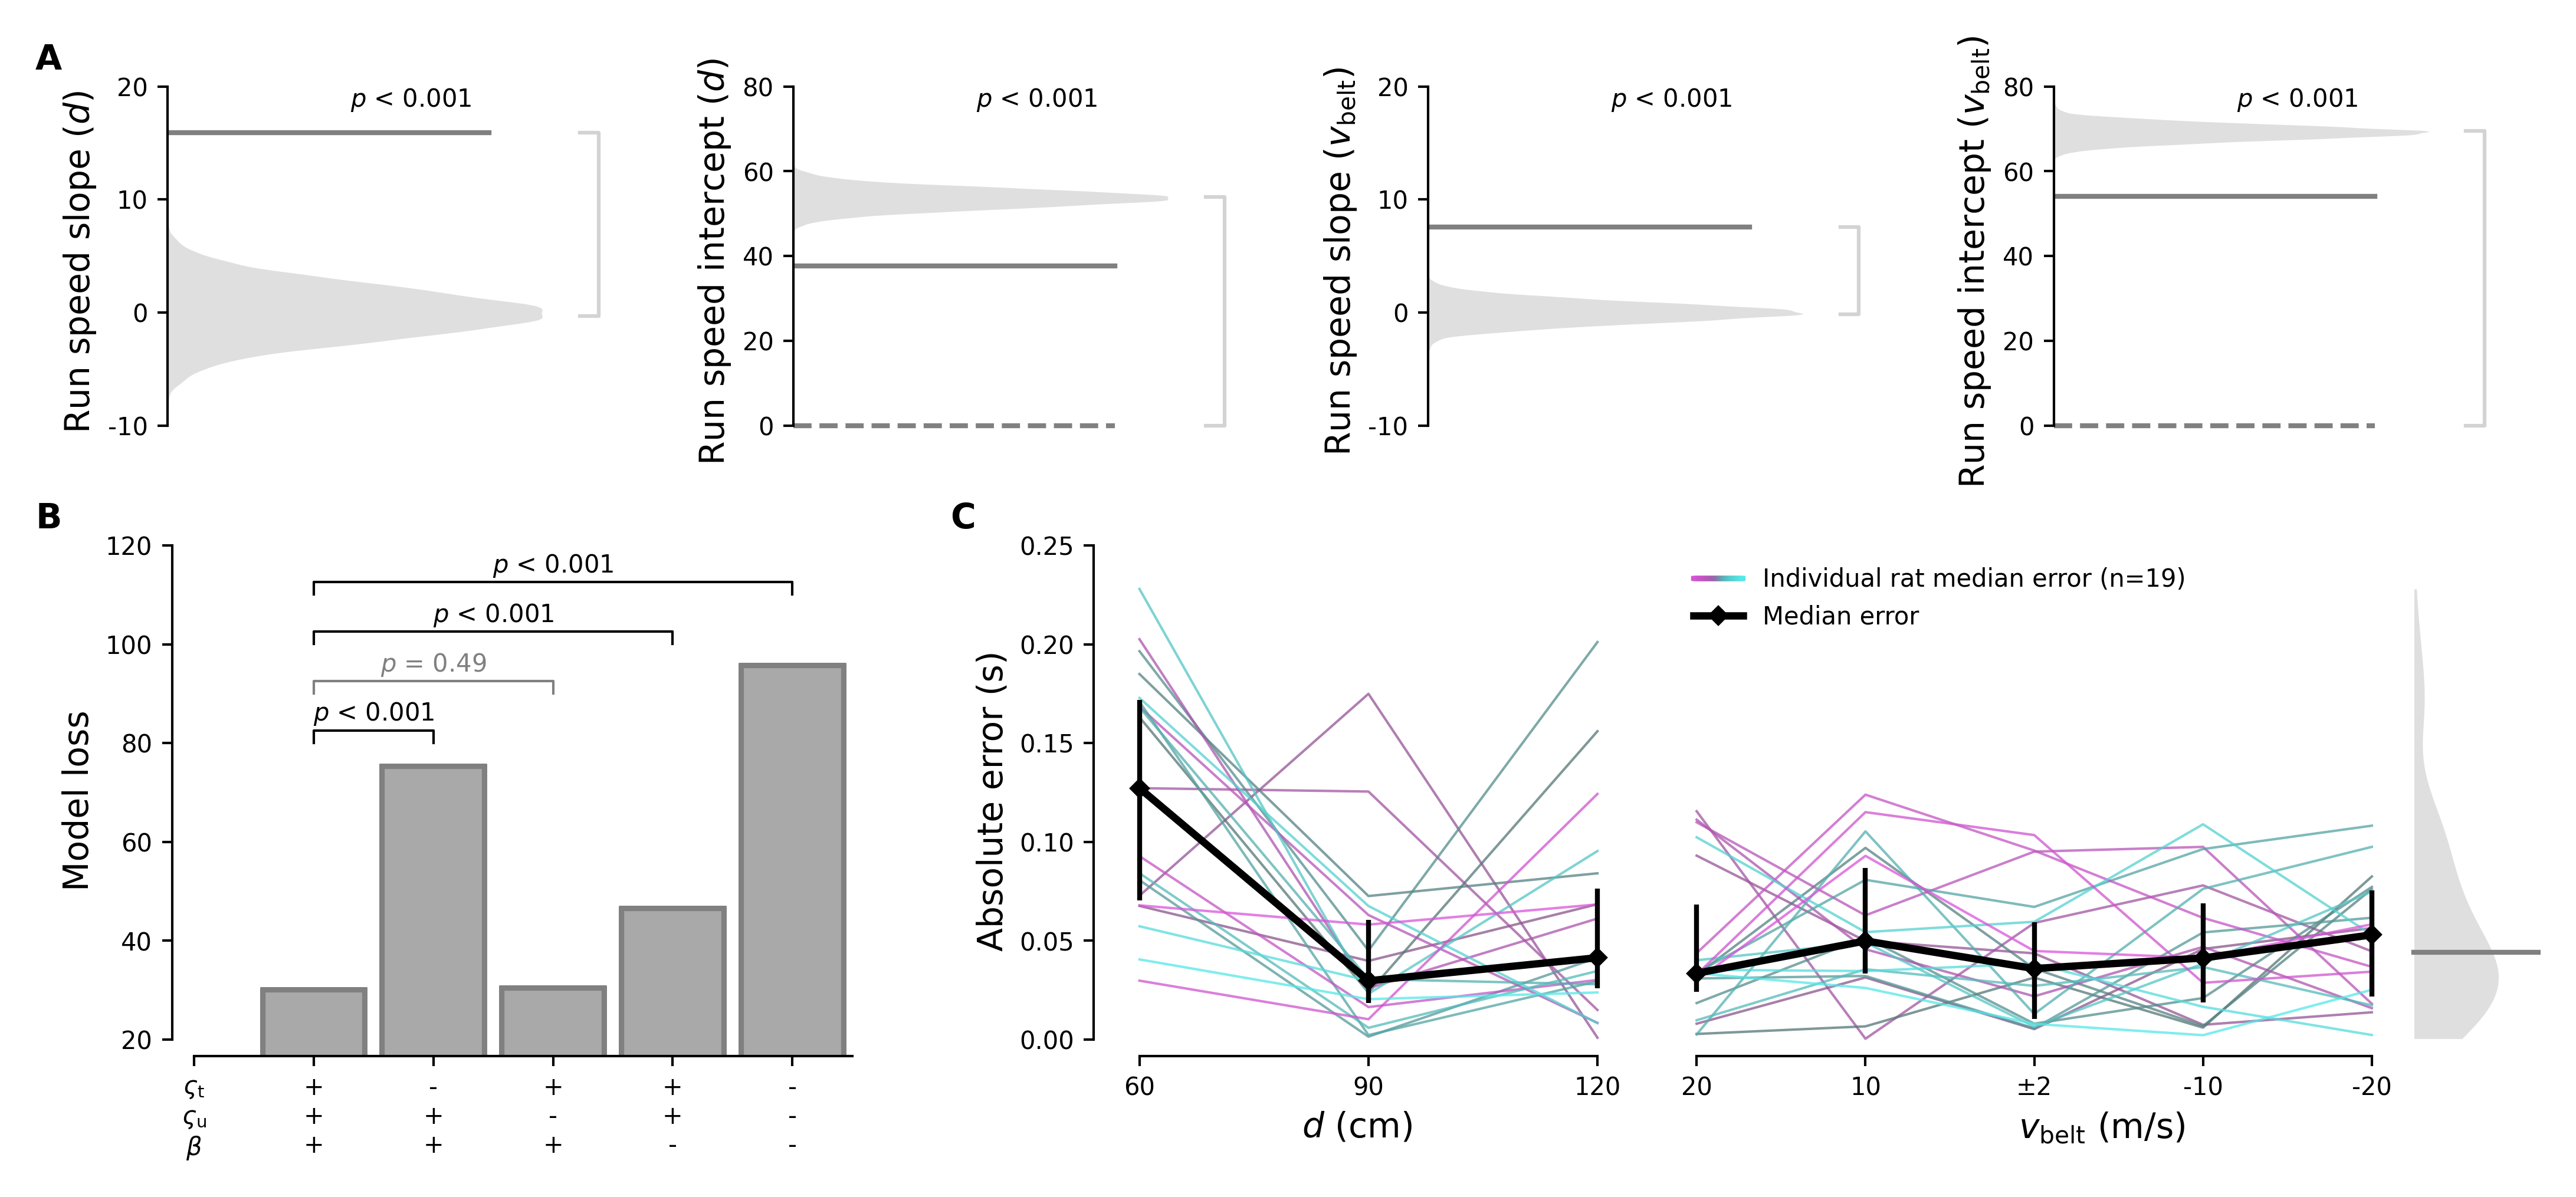

In [21]:
fig=plt.figure(figsize=(cm2inch(18), cm2inch(8)), 
               constrained_layout=True, facecolor='w', dpi=600)

gs = fig.add_gridspec(3, 1, height_ratios=[.6, 0.1, 1])
top_row = gs[0].subgridspec(1, 4)
ax_slope_dist = fig.add_subplot(top_row[0, 0])
ax_intercept_dist = fig.add_subplot(top_row[0, 1])
ax_slope_tm = fig.add_subplot(top_row[0, 2])
ax_intercept_tm = fig.add_subplot(top_row[0, 3])

bottom_row = gs[2].subgridspec(1, 4, width_ratios=[4, .1, 3, 5])
ax_ablation = fig.add_subplot(bottom_row[0, 0])
ax_error_dist = fig.add_subplot(bottom_row[0, 2])
ax_error_tm = fig.add_subplot(bottom_row[0, 3])

regression_permutation(run_speeds, dist_or_tm='dist', animal_list=intact_rats, color='gray',
                       varname_slope=r'Run speed slope ($d$)',
                        varname_intercept=r'Run speed intercept ($d$)',
                        ax_slope=ax_slope_dist, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds, dist_or_tm='tm', animal_list=intact_rats, color='gray',
                       varname_slope=r'Run speed slope ($v_{\mathrm{belt}}$)',
                        varname_intercept=r'Run speed intercept ($v_{\mathrm{belt}}$)',
                        ax_slope=ax_slope_tm, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm, y_ticks_intercept=[0, 20, 40, 60, 80])

FigureSXX(ax=ax_ablation)
FigureS7B(only_intact, ax_dist=ax_error_dist, ax_vbelt=ax_error_tm)

add_all_letters([ax_slope_dist,
                 ax_ablation, ax_error_dist], ["A", "B", "C"], verbose=True)

plt.savefig("./Figures_paper/Figure_SXXEffort.pdf", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)

plt.savefig("./Figures_paper/Figure_SXXEffort.svg", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="svg", dpi=600)